In [38]:
import pandas as pd


#import pandas as pd

#Carrega os dados
df = pd.read_csv('cid_mes_ano_col.csv', sep=';', encoding='latin1', skiprows=8, skipfooter=6, engine='python')

#Filtra apenas as linhas que contêm "Outubro" ou "Novembro"

#Isso ignora os totais anuais e outros meses que vieram por engano
df_sazonal = df[df['Ano/mês atendimento'].str.contains('Outubro|Novembro', na=False)].copy()

#Limpa o nome para ficar só "Outubro/2013" etc.
df_sazonal['Ano/mês atendimento'] = df_sazonal['Ano/mês atendimento'].str.replace('..', '', regex=False)

display(df_sazonal)

O Tabnet coloca pontos (..) antes dos nomes dos meses e espaços extras.
Tabnet coloca um hífen (-) para 0


In [39]:

tabela_cidmesano = pd.read_csv("cid_mes_ano_col.csv", sep=';', encoding='latin1', skipfooter=6, skiprows=8, engine='python')


display(tabela_cidmesano)


,Ano/mês atendimento,Menor 1 ano,1 a 4 anos,5 a 9 anos,Total
0,2011,1672,1304,516,3492
1,..Fevereiro/2011,-,1,-,1
2,..Abril/2011,4,1,1,6
3,..Maio/2011,2,1,1,4
4,..Junho/2011,16,4,-,20
...,...,...,...,...,...
119,Agosto/2025,61,31,24,116
120,Setembro/2025,224,203,91,518
121,Outubro/2025,940,710,337,1987
122,Novembro/2025,522,420,293,1235


O Tabnet coloca pontos (..) antes dos nomes dos meses e espaços extras.
Tabnet coloca um hífen (-) para 0

In [40]:
# Substituir os hifens por 0 - replace = substutuir

tabela_cidmesano = tabela_cidmesano.replace("-", 0)

# Limpar os pontos ".." do nome do mês. regex= busca padrões - str.strip"remover/aparar"()=limpa espaços

tabela_cidmesano['Ano/mês atendimento'] = tabela_cidmesano['Ano/mês atendimento'].str.replace("..", " ", regex=False).str.strip()


display(tabela_cidmesano)
print(tabela_cidmesano.dtypes)

,Ano/mês atendimento,Menor 1 ano,1 a 4 anos,5 a 9 anos,Total
0,2011,1672,1304,516,3492
1,Fevereiro/2011,0,1,0,1
2,Abril/2011,4,1,1,6
3,Maio/2011,2,1,1,4
4,Junho/2011,16,4,0,20
...,...,...,...,...,...
119,Agosto/2025,61,31,24,116
120,Setembro/2025,224,203,91,518
121,Outubro/2025,940,710,337,1987
122,Novembro/2025,522,420,293,1235


Ano/mês atendimento       str
Menor 1 ano            object
1 a 4 anos             object
5 a 9 anos             object
Total                   int64
dtype: object


As colunas com idade precisam ser lidas como numeral.

In [41]:
# Lista das colunas para transformar em números
colunas_para_converter = ["Menor 1 ano", "1 a 4 anos","5 a 9 anos", "Total"]
for coluna in colunas_para_converter:
    tabela_cidmesano[coluna] = pd.to_numeric(tabela_cidmesano[coluna])

    print(tabela_cidmesano.dtypes)

Ano/mês atendimento       str
Menor 1 ano             int64
1 a 4 anos             object
5 a 9 anos             object
Total                   int64
dtype: object
Ano/mês atendimento       str
Menor 1 ano             int64
1 a 4 anos              int64
5 a 9 anos             object
Total                   int64
dtype: object
Ano/mês atendimento      str
Menor 1 ano            int64
1 a 4 anos             int64
5 a 9 anos             int64
Total                  int64
dtype: object
Ano/mês atendimento      str
Menor 1 ano            int64
1 a 4 anos             int64
5 a 9 anos             int64
Total                  int64
dtype: object


Separa mês em ano em colunas

In [42]:

# criar colunas[]
# função, comando str(mostra que é uma string).split(corta quando acha uma /)
# expand=true fala para separalos em colunas diferentes

tabela_cidmesano[["Mês", "Ano"]] = tabela_cidmesano['Ano/mês atendimento'].str.split('/', expand=True)

# retirar a coluna
# retirar 'Ano/mês atendimento' - drop
#axis=1 coluna, axis=0 linha

tabela_cidmesano = tabela_cidmesano.drop('Ano/mês atendimento', axis=1)


In [43]:
display(tabela_cidmesano)

,Menor 1 ano,1 a 4 anos,5 a 9 anos,Total,Mês,Ano
0,1672,1304,516,3492,2011,NaN
1,0,1,0,1,Fevereiro,2011
2,4,1,1,6,Abril,2011
3,2,1,1,4,Maio,2011
4,16,4,0,20,Junho,2011
...,...,...,...,...,...,...
119,61,31,24,116,Agosto,2025
120,224,203,91,518,Setembro,2025
121,940,710,337,1987,Outubro,2025
122,522,420,293,1235,Novembro,2025


In [44]:
tabela_cidmesano = tabela_cidmesano.dropna(subset=['Ano'])
display(tabela_cidmesano)

,Menor 1 ano,1 a 4 anos,5 a 9 anos,Total,Mês,Ano
1,0,1,0,1,Fevereiro,2011
2,4,1,1,6,Abril,2011
3,2,1,1,4,Maio,2011
4,16,4,0,20,Junho,2011
5,60,27,2,89,Julho,2011
...,...,...,...,...,...,...
118,31,9,4,44,Julho,2025
119,61,31,24,116,Agosto,2025
120,224,203,91,518,Setembro,2025
121,940,710,337,1987,Outubro,2025


Buscar vários itens ao mesmo tempo em uma coluna, usamos o método .isin()= "está em"

In [45]:
tabela_sazonal = tabela_cidmesano[tabela_cidmesano['Mês'].isin(['Outubro', 'Novembro'])].copy()

display(tabela_sazonal)

,Menor 1 ano,1 a 4 anos,5 a 9 anos,Total,Mês,Ano
8,747,624,255,1626,Outubro,2011
9,398,342,149,889,Novembro,2011
16,507,547,232,1286,Outubro,2012
17,295,313,126,734,Novembro,2012
25,716,656,268,1640,Outubro,2013
26,401,427,168,996,Novembro,2013
34,615,721,229,1565,Outubro,2014
35,332,388,173,893,Novembro,2014
42,588,583,170,1341,Outubro,2015
43,336,347,127,810,Novembro,2015


Fazer análises - 

In [46]:
# Agrupar por Ano e somar o Total - reset_index = reorganiza a tabela

analise_anual = tabela_sazonal.groupby('Ano')['Total'].sum().reset_index()

# Vamos ver o resultado
display(analise_anual)

,Ano,Total
0,2011,2515
1,2012,2020
2,2013,2636
3,2014,2458
4,2015,2151
5,2016,2582
6,2017,2105
7,2018,3339
8,2019,3000
9,2020,785


Gráfico - matplotlib.pyplot as plt

grafico de linha .plot()
grafico de barra .bar()

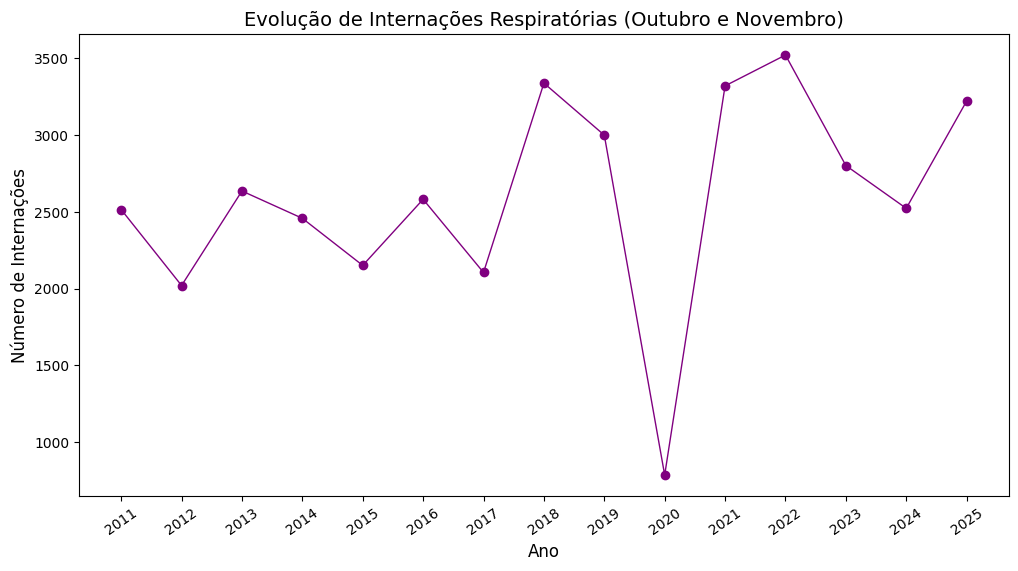

In [47]:
import matplotlib.pyplot as plt


# Definir o tamanho da figura
plt.figure(figsize=(12, 6))

# Criar o gráfico de linha
# x = Ano, y = Total
plt.plot(analise_anual["Ano"], analise_anual["Total"], marker="o", linestyle="-", color="purple", linewidth=1)
# AJUSTE DO EIXO X: Mostra cada ano exatamente abaixo do ponto
plt.xticks(analise_anual["Ano"], rotation=35)

# Personalizar (Títulos e Legendas)
plt.title("Evolução de Internações Respiratórias (Outubro e Novembro)", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Internações", fontsize=12)


# Mostrar o gráfico
plt.show()

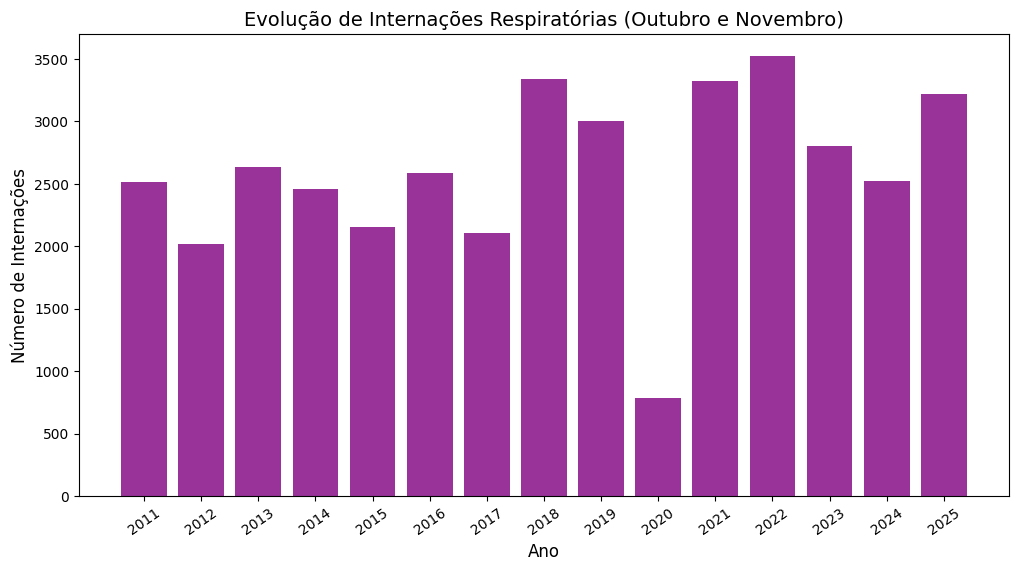

In [48]:


# Definir o tamanho da figura
plt.figure(figsize=(12, 6))

# Criar o gráfico de BARRA
# Trocamos .plot por .bar
plt.bar(analise_anual["Ano"], analise_anual["Total"], color="purple", alpha=0.8)

# AJUSTE DO EIXO X: Mantemos igual para aparecerem todos os anos
plt.xticks(analise_anual["Ano"], rotation=35)

# Personalizar
plt.title("Evolução de Internações Respiratórias (Outubro e Novembro)", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Internações", fontsize=12)

plt.show()

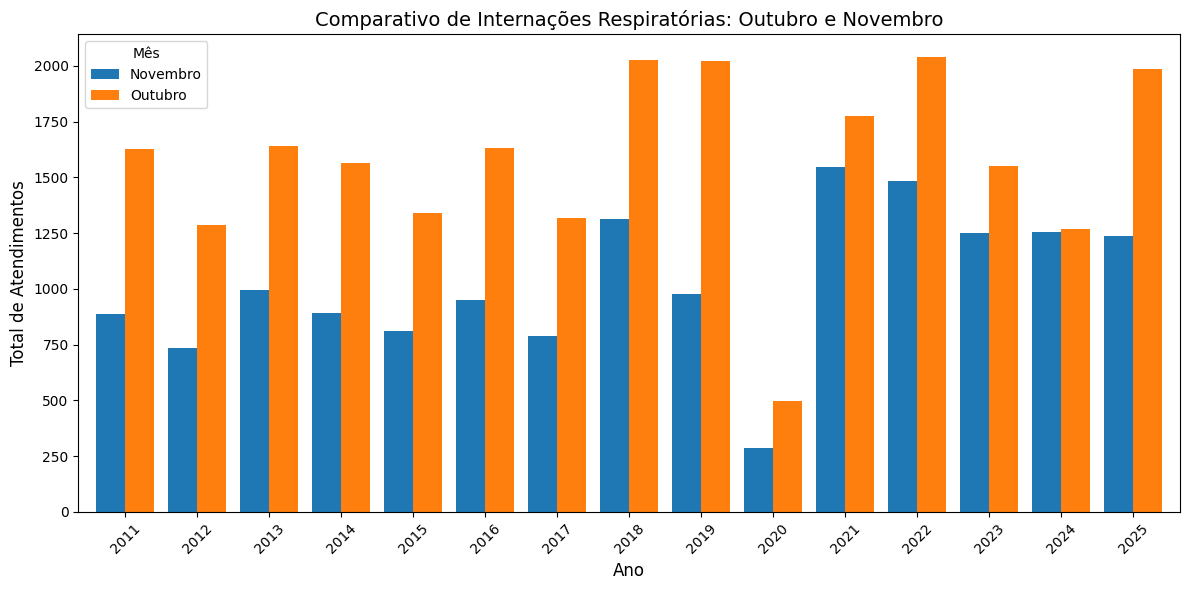

In [49]:
#index eixo x
df_plot = tabela_sazonal.pivot(index="Ano", columns="Mês", values="Total")

ax = df_plot.plot(kind="bar", figsize=(12, 6), width=0.8)

plt.title("Comparativo de Internações Respiratórias: Outubro e Novembro", fontsize=14)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Total de Atendimentos", fontsize=12)
plt.xticks(rotation=45) # Inclinar os anos para melhor leitura
plt.legend(title="Mês")

plt.tight_layout()
plt.show()

Reordenar colunas e mudar as cores

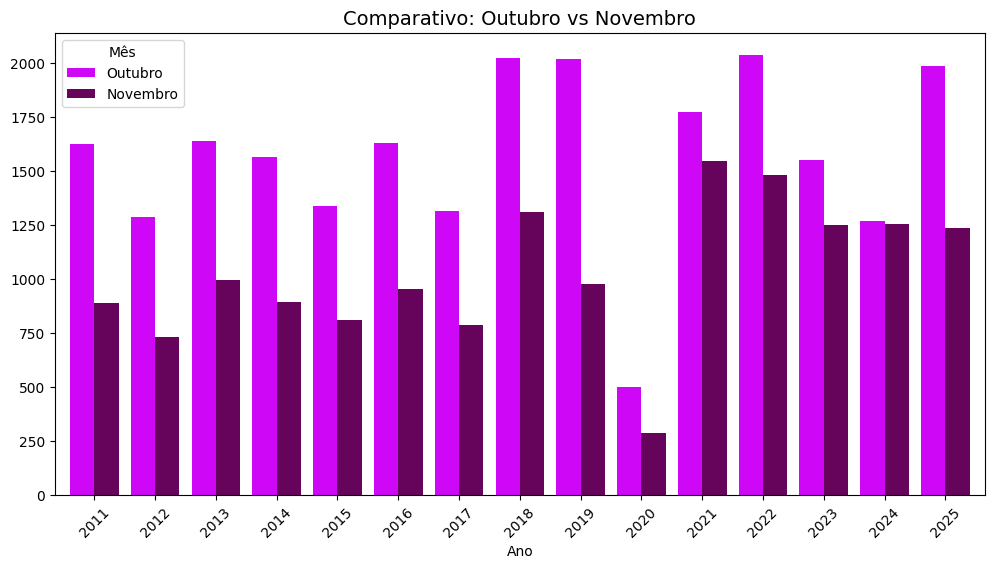

In [50]:
df_plot = df_plot[["Outubro", "Novembro"]]

minhas_cores = ["#CF07F7", "#66035A"] 
#Plotar com a nova ordem e cores
ax = df_plot.plot(kind="bar", 
                  figsize=(12, 6), 
                  width=0.8, 
                  color=minhas_cores)

# Personalização extra
ax.set_title("Comparativo: Outubro vs Novembro", fontsize=14)
ax.set_xticklabels(df_plot.index, rotation=45)

plt.show()